06 — MLP

A 3-layer feed-forward network on the same 28 features as the trees and linear
models. Hidden sizes 256/128/64, ReLU activations, 0.3 dropout, Adam optimiser,
early stopping on validation MSE. The proposal hypothesises (per Grinsztajn et
al. 2022) that this MLP will not outperform LightGBM on tabular data; this
notebook confirms that and looks at where the gap is largest.

In [1]:
from __future__ import annotations

import warnings
warnings.filterwarnings("ignore")

import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("MPLCONFIGDIR", str(__import__("pathlib").Path.cwd() / ".mplcache"))
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)

from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import load_config
from src.pipeline import prepare_data
from src.models import MLPModel, LightGBMModel
from src.viz.style import set_style, save_figure, PRIMARY, ACCENT, SUPPORT

set_style()
PLOT_DIR = Path("../results/plots/mlp")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

cfg = load_config("../configs/default.yaml")
prep = prepare_data(cfg, feature_set="engineered")
X_train, y_train = prep.train_full[prep.feature_cols], prep.target_log_train
X_val, y_val = prep.val_full[prep.feature_cols], prep.target_log_val


In [2]:
mlp_params = cfg.models.get("mlp", {})
mlp = MLPModel(**mlp_params)
t0 = time.time()
mlp.fit(X_train, y_train, eval_set=(X_val, y_val))
mlp_secs = time.time() - t0
mlp_preds = mlp.predict(X_val)
y_val_real = np.expm1(np.clip(y_val, 0.0, 14.0))
mlp_real = np.expm1(np.clip(mlp_preds, 0.0, 14.0))
mlp_rmse = float(np.sqrt(np.mean((mlp_real - y_val_real) ** 2)))
print(f"MLP RMSE: {mlp_rmse:.1f}   ({mlp_secs:.1f}s)")


MLP RMSE: 9916.1   (265.1s)


MLP vs. LightGBM

Same data, same features, same split.

In [3]:
lgb = LightGBMModel(**cfg.models.get("lightgbm", {}))
lgb.fit(X_train, y_train, eval_set=(X_val, y_val))
lgb_preds = lgb.predict(X_val)
lgb_real = np.expm1(np.clip(lgb_preds, 0.0, 14.0))
lgb_rmse = float(np.sqrt(np.mean((lgb_real - y_val_real) ** 2)))
print(f"LightGBM RMSE: {lgb_rmse:.1f}")


LightGBM RMSE: 5730.6


Predicted vs. actual side by side

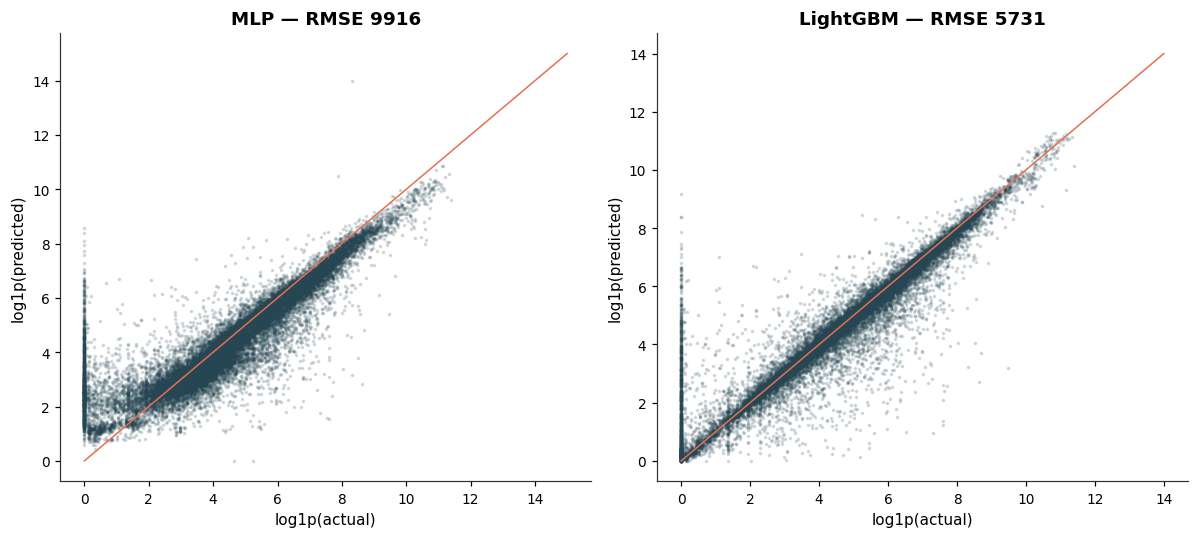

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, name, pr in [(axes[0], "MLP", mlp_real), (axes[1], "LightGBM", lgb_real)]:
    sample = np.random.default_rng(0).choice(len(pr), size=min(30_000, len(pr)), replace=False)
    ax.scatter(np.log1p(y_val_real[sample]), np.log1p(pr[sample]),
               s=2, alpha=0.15, color=PRIMARY)
    lo = 0; hi = max(np.log1p(y_val_real.max()), np.log1p(pr.max()) + 1)
    ax.plot([lo, hi], [lo, hi], color=ACCENT, linewidth=1)
    rm = float(np.sqrt(np.mean((pr - y_val_real) ** 2)))
    ax.set_title(f"{name} — RMSE {rm:.0f}")
    ax.set_xlabel("log1p(actual)")
    ax.set_ylabel("log1p(predicted)")
plt.tight_layout()
save_figure(fig, PLOT_DIR / "mlp_vs_lgbm")
plt.show()


Where MLP loses ground

Per-primary-use RMSE ratio: MLP / LightGBM. Ratios above 1 are the categories
where MLP is worse.

In [5]:
val = prep.val_full.copy()
val["y_true"] = y_val_real
val["y_pred_mlp"] = mlp_real
val["y_pred_lgb"] = lgb_real

agg = (
    val.groupby("primary_use", observed=True)
       .apply(lambda d: pd.Series({
           "mlp_rmse": float(np.sqrt(np.mean((d["y_pred_mlp"] - d["y_true"]) ** 2))),
           "lgbm_rmse": float(np.sqrt(np.mean((d["y_pred_lgb"] - d["y_true"]) ** 2))),
           "n": len(d),
       }))
)
agg["mlp_over_lgbm"] = agg["mlp_rmse"] / agg["lgbm_rmse"]
agg = agg.sort_values("mlp_over_lgbm", ascending=False)
agg


,mlp_rmse,lgbm_rmse,n,mlp_over_lgbm
primary_use,,,,
Technology/science,23.920670,6.948022,6623.0,3.442803
Other,102.973465,40.212183,8828.0,2.560753
Warehouse/storage,47.826168,20.038531,12786.0,2.386710
Utility,321.443561,155.363924,6622.0,2.068972
Office,2109.812968,1069.853124,616371.0,1.972059
Public services,1131.352790,619.025523,107052.0,1.827635
Parking,442.518849,245.694072,35295.0,1.801097
Healthcare,910.085098,505.593730,77894.0,1.800032
Education,16506.180924,9540.304995,694452.0,1.730152


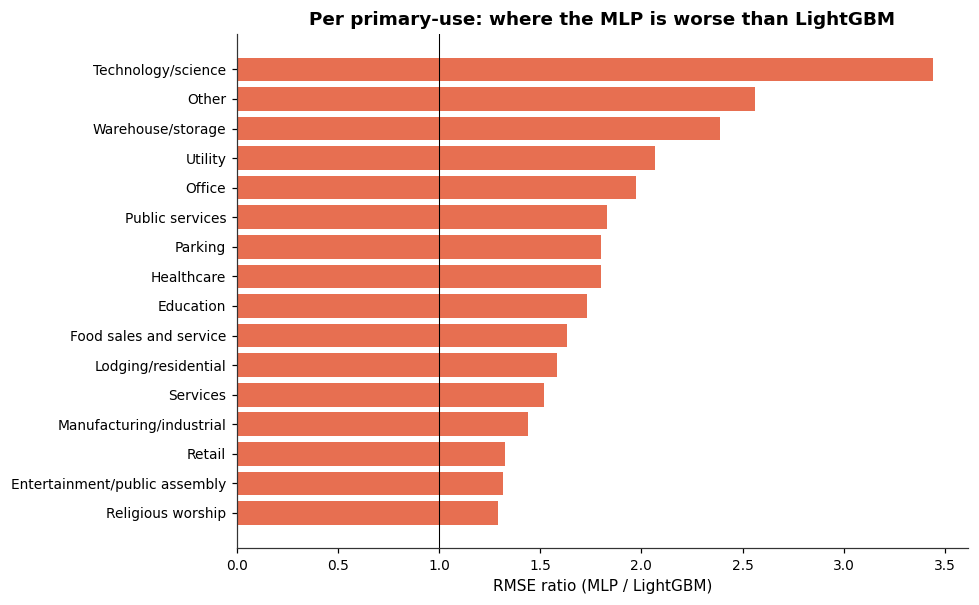

In [6]:
fig, ax = plt.subplots(figsize=(9, max(3, 0.35 * len(agg))))
colors = [ACCENT if r > 1 else PRIMARY for r in agg["mlp_over_lgbm"]]
ax.barh(agg.index[::-1], agg["mlp_over_lgbm"].values[::-1], color=colors[::-1])
ax.axvline(1.0, color="black", linewidth=0.7)
ax.set_xlabel("RMSE ratio (MLP / LightGBM)")
ax.set_title("Per primary-use: where the MLP is worse than LightGBM")
plt.tight_layout()
save_figure(fig, PLOT_DIR / "mlp_vs_lgbm_per_use")
plt.show()


In [7]:
out_dir = Path("../results/tables")
out_dir.mkdir(parents=True, exist_ok=True)
agg.to_csv(out_dir / "mlp_vs_lgbm_per_primary_use.csv")
pd.DataFrame({"model": ["mlp", "lightgbm"],
              "rmse": [mlp_rmse, lgb_rmse]}).to_csv(out_dir / "mlp_summary.csv", index=False)
print(f"wrote {out_dir}/mlp_vs_lgbm_per_primary_use.csv and {out_dir}/mlp_summary.csv")


wrote ../results/tables/mlp_vs_lgbm_per_primary_use.csv and ../results/tables/mlp_summary.csv
